# MSA 2026 Phase 2 - Part 1

In [2]:
# !pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable
     ---------------------------------------- 0.0/80.3 kB ? eta -:--:--
     --------- ---------------------------- 20.5/80.3 kB 330.3 kB/s eta 0:00:01
     --------------------------------- ---- 71.7/80.3 kB 787.7 kB/s eta 0:00:01
     -------------------------------------- 80.3/80.3 kB 744.9 kB/s eta 0:00:00
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ---------------------------------------- 0.0/121.0 kB ? eta -:--:--
     -------------------------------------- 121.0/121.0 kB 2.4 MB/s eta 0:00:00
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/9.3 MB ?


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import sklearn
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

## 1. Find all variables and understand them

In [ ]:
# Load X store sales data & preview the first 10 rows
xsales_data = pd.read_csv('datasets/X store sales/store_sales.csv', encoding='latin1')
xsales_data.head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
3,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
4,11,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092
5,24,US-2017-156909,7/16/2017,7/18/2017,Second Class,SF-20065,Sandra Flanagan,Consumer,United States,Philadelphia,...,19140,East,FUR-CH-10002774,Furniture,Chairs,"Global Deluxe Stacking Chair, Gray",71.3720,2,0.30,-1.0196
6,25,CA-2015-106320,9/25/2015,9/30/2015,Standard Class,EB-13870,Emily Burns,Consumer,United States,Orem,...,84057,West,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,1044.6300,3,0.00,240.2649
7,28,US-2015-150630,9/17/2015,9/21/2015,Standard Class,TB-21520,Tracy Blumstein,Consumer,United States,Philadelphia,...,19140,East,FUR-BO-10004834,Furniture,Bookcases,"Riverside Palais Royal Lawyers Bookcase, Royal...",3083.4300,7,0.50,-1665.0522
8,30,US-2015-150630,9/17/2015,9/21/2015,Standard Class,TB-21520,Tracy Blumstein,Consumer,United States,Philadelphia,...,19140,East,FUR-FU-10004848,Furniture,Furnishings,"Howard Miller 13-3/4"" Diameter Brushed Chrome ...",124.2000,3,0.20,15.5250
9,37,CA-2016-117590,12/8/2016,12/10/2016,First Class,GH-14485,Gene Hale,Corporate,United States,Richardson,...,75080,Central,FUR-FU-10003664,Furniture,Furnishings,"Electrix Architect's Clamp-On Swing Arm Lamp, ...",190.9200,5,0.60,-147.9630


In [11]:
# view time range of the data
xsales_data['Order Date'] = pd.to_datetime(xsales_data['Order Date'])
print('Data covers from {} to {}'.format(xsales_data['Order Date'].min(), xsales_data['Order Date'].max()))

Data covers from 2014-01-06 00:00:00 to 2017-12-30 00:00:00


In [12]:
# key statistical measures of the sales/quantity/discount/profit columns
xsales_data[['Sales', 'Quantity', 'Discount', 'Profit']].describe()

,Sales,Quantity,Discount,Profit
count,2121.000000,2121.000000,2121.000000,2121.000000
mean,349.834887,3.785007,0.173923,8.699327
std,503.179145,2.251620,0.181547,136.049246
min,1.892000,1.000000,0.000000,-1862.312400
25%,47.040000,2.000000,0.000000,-12.849000
50%,182.220000,3.000000,0.200000,7.774800
75%,435.168000,5.000000,0.300000,33.726600
max,4416.174000,14.000000,0.700000,1013.127000


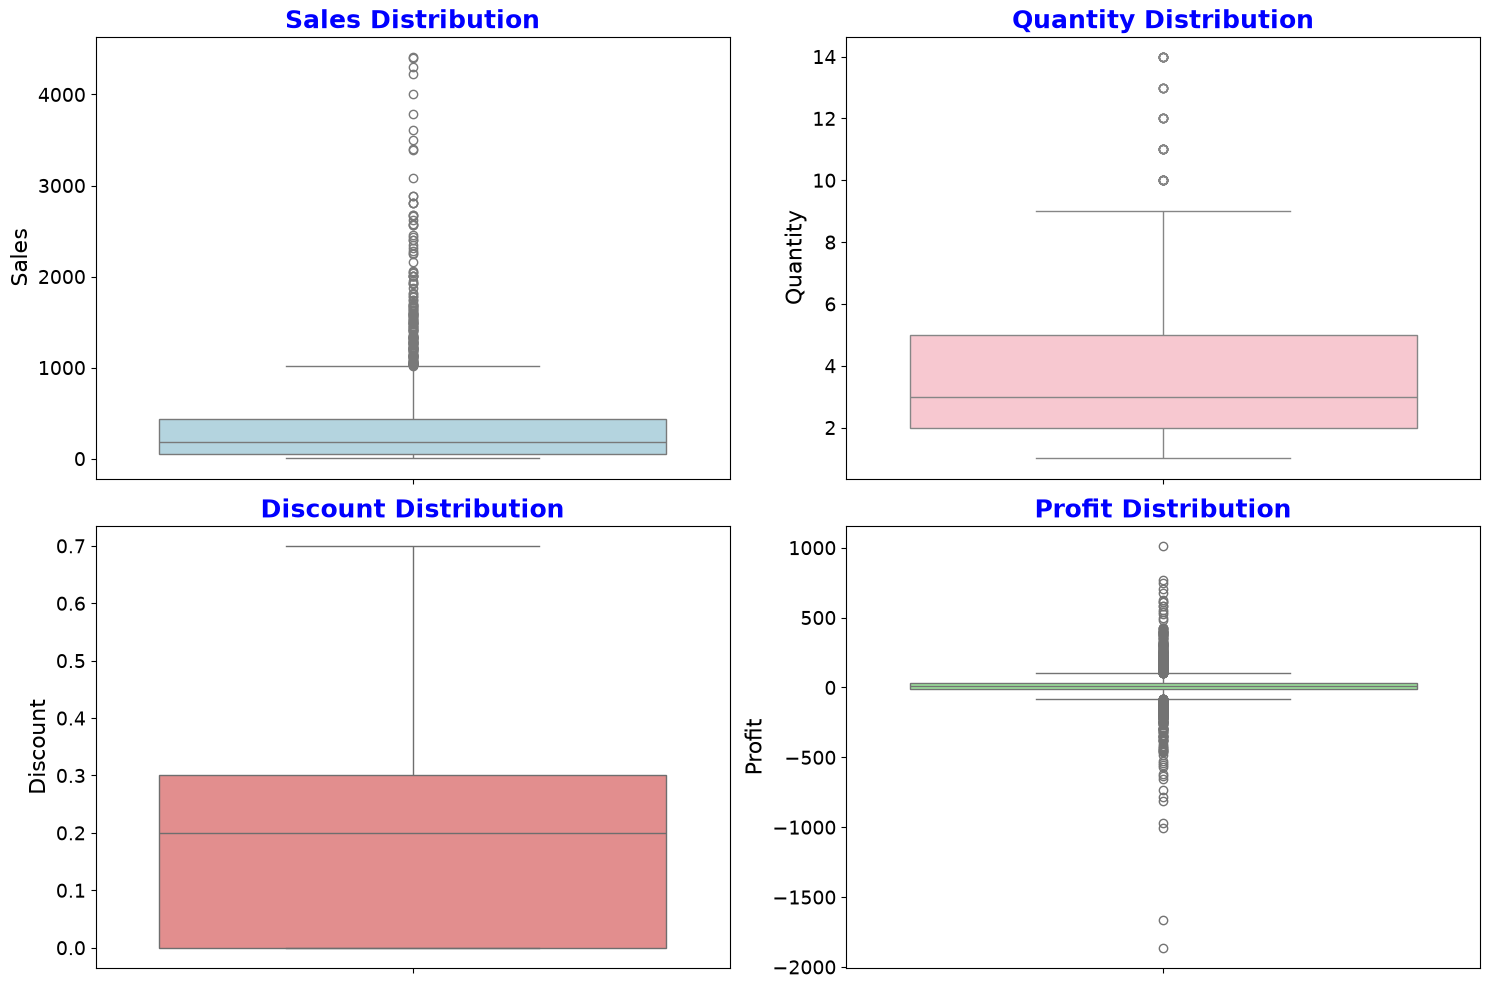

In [ ]:
# visualize the distribution of sales, quantity, discount and 
# profit using boxplots to check data distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
sns.boxplot(data=xsales_data['Sales'], ax=axes[0, 0], color='lightblue')
sns.boxplot(data=xsales_data['Quantity'], ax=axes[0, 1], color='pink')
sns.boxplot(data=xsales_data['Discount'], ax=axes[1, 0], color='lightcoral')
sns.boxplot(data=xsales_data['Profit'], ax=axes[1, 1], color='lightgreen')

# Set title and label format for all subplots
# Titles for each subplot
titles = [
    "Sales Distribution",
    "Quantity Distribution",
    "Discount Distribution",
    "Profit Distribution"
]

# Style settings
title_style = {
    'fontsize': 18,
    'fontweight': 'bold',
    'color': 'blue'
}

label_size = 16
tick_size = 14

# Apply to all subplots
for ax, title in zip(axes.flat, titles):

    # Title
    ax.set_title(title, **title_style)

    # Axis labels
    ax.set_xlabel(ax.get_xlabel(), fontsize=label_size)
    ax.set_ylabel(ax.get_ylabel(), fontsize=label_size)

    # Tick labels
    ax.tick_params(axis='both', labelsize=tick_size)

# set all x and y labels with font size 16; set all x ticks with font size 12
plt.tight_layout()
plt.show()


In [13]:
# view the distribution of sales, quantity, discount and profit by year
# extract year from order date and create a new column for it
xsales_data['Year'] = xsales_data['Order Date'].dt.year
# group by year and get statistical measures of sales, quantity, discount and profit for each year
yearly_stats = xsales_data.groupby('Year')[['Sales', 'Quantity', 'Discount', 'Profit']].describe()
yearly_stats

Sales                                                             \
      count        mean         std    min     25%      50%        75%   
Year                                                                     
2014  421.0  373.379699  525.313524  3.480  51.940  181.470  512.35800   
2015  452.0  377.252737  580.492807  2.960  54.234  191.890  414.15525   
2016  562.0  353.917146  477.052252  2.328  47.130  186.060  454.01175   
2017  686.0  313.975611  451.679254  1.892  41.960  171.288  381.94350   

               Quantity            ... Discount      Profit             \
           max    count      mean  ...      75%  max  count       mean   
Year                               ...                                   
2014  4007.840    421.0  3.855107  ...      0.3  0.7  421.0  12.963719   
2015  4404.900    452.0  3.926991  ...      0.2  0.7  452.0   6.670803   
2016  3504.900    562.0  3.902135  ...      0.3  0.7  562.0  12.384258   
2017  4416.174    686.0  3.552478  ...      0.2  0.7  686.0   4.399987   

                                                                      
             std        min        25%      50%       75%        max  
Year                                                                  
2014  120.658083  -734.5264 -14.229000   7.6965  30.02340   746.4078  
2015  177.955506 -1862.3124 -12.298800  10.1760  40.86015  1013.1270  
2016  121.739478  -814.4832 -12.060400   8.2542  34.25890   700.9800  
2017  123.801918 -1002.7836 -13.752675   6.8726  28.42985   609.7157  

[4 rows x 32 columns]

## 2. Clean data

In [3]:
#

## 3. Visualise data

In [4]:
#

## 4. Identify correlated variables

In [5]:
#

## 5. Summary